In [1]:
import numpy as np
import pandas as pd
import cvxpy as cp
import seaborn as sns
import mosek
import matplotlib.pyplot as plt
import datetime as date
from datetime import datetime as dt
from dateutil.relativedelta import *
import scipy.stats
from scipy.stats import rankdata
from itertools import chain, combinations
from Hit_and_Run import hit_and_run

In [2]:
def powerset(iterable):
    "powerset([1,2,3]) --> () (1,) (2,) (3,) (1,2) (1,3) (2,3) (1,2,3)"
    s = list(iterable)
    return chain.from_iterable(combinations(s, r) for r in range(len(s)+1))


In [3]:

def kullback_leibler(p,q,r,par,constraints):
    N = p.shape[0]
    phi_cons = 0
    for i in range(N):
        phi_cons = phi_cons -cp.entr(q[i]) - q[i]*np.log(p[i])
    constraints.append(phi_cons<=r)
    return(constraints)


def kullback_leibler_conj(gamma,w,s,t,constraints):
    N = s.shape[0]
    constraints.append(w - gamma*(np.zeros(N)+1) <= t)
    for i in range(N):
        constraints.append(cp.kl_div(gamma,w[i])+gamma+s[i]-w[i]<= 0)
    return(constraints)


In [4]:
def h_single_power(x,par):
    return(1-(np.abs(1-x))**par)

def h_sing_power(q_b,q,rank,par,constraints):
    N = q.shape[0]
    for i in range(N-1):
        v = 1-cp.power((1-cp.sum(q[rank[0:i+1]])),par)
        constraints.append(cp.sum(q_b[rank[0:i+1]])-v <= 0)
    return(constraints)

def h_sing_power_conj(lbda,v,z,par,constraints):
    M = lbda.shape[0]
    xi_2 = cp.Variable(M, nonneg = True)
    xi_3 = cp.Variable(M, nonneg = True)
    xi_4 = cp.Variable(M, nonneg = True)
    constraints.extend((xi_3 <= xi_2, xi_3 <= v))
    constraints.append(lbda-xi_3+(par**(-1/(par-1))-par**(-par/(par-1)))*xi_4 <= z)
    exponent = np.array([(par-1)/par,1-(par-1)/par])
    for j in range(M):
        constraints.append(xi_2[j]-cp.geo_mean(cp.vstack([xi_4[j],lbda[j]]),exponent)<= 0)
    return(constraints)

def h_pow(x,par):
    return(x**par)

def h_power(q_b,q,rank,par,constraints):
    N = q.shape[0]
    for i in range(N-1):
        constraints.append(cp.sum(q_b[rank[0:i+1]])-cp.power(cp.sum(q[rank[0:i+1]]),par) <= 0)
    return(constraints)

def h_power_conj(lbda,v,z,par,constraints):
    M = lbda.shape[0]
    constraints.append(v >= 0)
    const = (par**(par/(1-par))-par**(1/(1-par)))**(1-par)
    exp = np.array([1-par, par])
    for j in range(M):
        constraints.append(cp.geo_mean(cp.vstack([z[j],v[j]]),exp)>= lbda[j]*const)
    return(constraints)

def h_cv(x, par):
    return(np.minimum(x/(1-par),1))

def h_cvar(q_b, q, rank, par, constraints):
    constraints.append(q_b<= q/(1-par))
    return(constraints)

def h_cvar_conj(lbda,v,z,par,constraints):
    M = lbda.shape[0]
    for j in range(M):
        constraints.append(cp.pos(-(1-par)*v[j]+lbda[j])<= z)
    constraints.append(v >= 0)
    return(constraints)

def h_lin(x,par):
    return(x)

def h_linear(q_b, q, rank, par, constraints):
    constraints.append(q_b <= q)
    return(constraints)

def h_linear_conj(lbda,v,z,par,constraints):
    constraints.append(v>=lbda)
    constraints.append(z >= 0)
    return(constraints)

In [92]:
def RC_newsvendor_portfolio(sets,p,d,r,par,par_news,c,phi_conj, h_conj):
    N = len(p)
    M = len(sets)
    v = cp.Variable(M)
    lbda = cp.Variable(M, nonneg = True)
    y = cp.Variable(1, nonneg = True)
    alpha, alpha1, beta, t1 = [cp.Variable(1), cp.Variable(1), cp.Variable(1), cp.Variable(1)]
    gamma, gamma1 = [cp.Variable(1,nonneg = True), cp.Variable(1,nonneg = True)]
    [v_news, l_news, s_news, c_news] = par_news
    t, t3 = [cp.Variable(N), cp.Variable(N)]
    z = cp.Variable(M)
    z2 = cp.Variable(N)
    s = cp.Variable(N)
    s3 = cp.Variable(N)
    w1, w2_phi, w3_phi = [cp.Variable(N), cp.Variable(N), cp.Variable(N)]
    l1 = (v_news+l_news-c_news)*y*(np.zeros(N)+1) - l_news*d
    l2 = (s_news-c_news)*y*(np.zeros(N)+1) + (v_news-s_news)*d
    constraints = [y<= 100, w1 <= l1, w1 <= l2, z2 <= l1, z2 <= l2]
    for i in range(N):
        lbdasum = 0
        vsum = 0
        for j in range(M):
            if i in sets[j]:
                lbdasum = lbdasum + lbda[j]
                vsum = vsum + v[j]
        constraints.append(-z2[i] - lbdasum - beta <= 0)
        constraints.append(s[i] == -alpha + vsum)
    constraints = phi_conj(gamma,w2_phi,s,t,constraints)
    constraints = h_conj(lbda,v,z,par,constraints)
    constraints.append(alpha + beta + gamma * r  + cp.sum(z) + p@t <= c)
    s3 = -w1-alpha1*(np.zeros(N)+1)
    constraints = phi_conj(gamma1,w3_phi,s3,t3,constraints)
    constraints.append(alpha1 + gamma1*r + p@t3 <= -t1)
    obj = cp.Maximize(t1)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(y.value, -prob.value)

def robustcheck_newsvendor(y,d,r,p,par,par_news,h_func, phi_func):
    N = len(p)
    x = np.zeros(N)
    [v_news, l_news, s_news, c_news] = par_news
    for i in range(N):
        x[i] = v_news*np.minimum(d[i],y)+s_news*np.maximum(y-d[i],0)-l_news*np.maximum(d[i]-y,0)-c_news*y
    rank = np.argsort((-x))
    q_b = cp.Variable(N, nonneg = True)
    q = cp.Variable(N, nonneg=True)
    constraints = [cp.sum(q) == 1, cp.sum(q_b)==1]
    constraints = h_func(q_b,q,rank,par,constraints)
    constraints = phi_func(p,q,r,par,constraints)
    obj = cp.Maximize(-q_b.T @ x)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(prob.value,q_b.value)

In [89]:
def RC_newsvendor_riskmin(sets,p,d,r,par,par_news,phi_conj, h_conj):
    N = len(p)
    M = len(sets)
    v = cp.Variable(M)
    lbda = cp.Variable(M, nonneg = True)
    y = cp.Variable(1, nonneg = True)
    alpha, beta, c = [cp.Variable(1), cp.Variable(1), cp.Variable(1)]
    gamma = cp.Variable(1,nonneg = True)
    [v_news, l_news, s_news, c_news] = par_news
    z = cp.Variable(M)
    t, z2 = [cp.Variable(N), cp.Variable(N)]
    s = cp.Variable(N)
    w2_phi = cp.Variable(N)
    l1 = (v_news+l_news-c_news)*y*(np.zeros(N)+1) - l_news*d
    l2 = (s_news-c_news)*y*(np.zeros(N)+1) + (v_news-s_news)*d
    constraints = [y<= 100, z2 <= l1, z2 <= l2]
    for i in range(N):
        lbdasum = 0
        vsum = 0
        for j in range(M):
            if i in sets[j]:
                lbdasum = lbdasum + lbda[j]
                vsum = vsum + v[j]
        constraints.append(-z2[i] - lbdasum - beta <= 0)
        constraints.append(s[i] == -alpha + vsum)
    constraints = phi_conj(gamma,w2_phi,s,t,constraints)
    constraints = h_conj(lbda,v,z,par,constraints)
    constraints.append(alpha + beta + gamma * r  + cp.sum(z) + p@t <= c)
    obj = cp.Maximize(-c)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(y.value, -prob.value)

def nominal_solve(sets,p,d,par,par_news, h_eva):
    N = len(p)
    M = len(sets)
    lbda = cp.Variable(M, nonneg = True)
    y = cp.Variable(1, nonneg = True)
    beta, c = [cp.Variable(1), cp.Variable(1)]
    [v_news, l_news, s_news, c_news] = par_news
    z2 = cp.Variable(N)
    l1 = (v_news+l_news-c_news)*y*(np.zeros(N)+1) - l_news*d
    l2 = (s_news-c_news)*y*(np.zeros(N)+1) + (v_news-s_news)*d
    constraints = [y<= 100, z2 <= l1, z2 <= l2]
    h_jsum = 0
    for i in range(N):
        lbdasum = 0
        for j in range(M):
            if i in sets[j]:
                lbdasum = lbdasum + lbda[j]
        constraints.append(-z2[i] - lbdasum - beta <= 0)
    for j in range(M):
         h_jsum = h_jsum + lbda[j]*h_eva(np.sum(p[sets[j]]),par)
    constraints.append(beta  + h_jsum <= c)
    obj = cp.Maximize(-c)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(y.value, -prob.value)

def nominal_risk(y,d,p,par,par_news, h_eva):
    N = len(p)
    [v_news, l_news, s_news, c_news] = par_news
    x = np.zeros(N)
    for i in range(N):
        x[i] = v_news*np.minimum(d[i],y)+s_news*np.maximum(y-d[i],0)-l_news*np.maximum(d[i]-y,0)-c_news*y
    rank = np.argsort(x)
    q_b = np.zeros(N)
    q_b[0] = h_eva(p[rank[0]],par)
    risk = -q_b[0]*x[rank[0]]
    for i in range(1,N):
        q_b[i] = h_eva(np.sum(p[rank[0:i+1]]),par)-h_eva(np.sum(p[rank[0:i]]),par)
        risk = risk - q_b[i]*x[rank[i]]
    return(risk)

In [109]:
d = np.array([4,8,10])
N = 1000
m = len(d)
p = np.array([0.375,0.375,0.25])
par = 3
par_news = np.array([6,4,2,4])
phi_dot = 1
r = phi_dot/(2*N)*scipy.stats.chi2.ppf(0.95, N)
#c = 5
phi_conj = kullback_leibler_conj
h_conj = h_sing_power_conj
phi_func = kullback_leibler
h_func = h_sing_power
h_eva = h_single_power

In [28]:
r

0.6217105670200204

In [75]:
psets = list(powerset(list(range(m))))
for i in range(1,len(psets)):
    psets[i] = list(psets[i])
psets = psets[1:(len(psets)-1)]
sets = psets

In [110]:
news_result = RC_newsvendor_riskmin(sets,p,d,r,par,par_news,phi_conj, h_conj)
print(news_result)

(array([7.00000012]), -1.9999980896017098)


In [111]:
news_nom_result = nominal_solve(sets,p,d,par,par_news, h_eva)
print(news_nom_result)

(array([7.]), -2.4218749999999876)


In [104]:
robustcheck_newsvendor(news_result[0],d,r,p,par,par_news,h_func, phi_func)

(-1.9999998241887447, array([1., 0., 0.]))

In [105]:
robustcheck_newsvendor(news_nom_result[0],d,r,p,par,par_news,h_func, phi_func)

(0.7766638552163485, array([1., 0., 0.]))

In [15]:
nominal_risk(news_result[0],d,p,par,par_news, h_eva)

-3.125000073182308

In [106]:
np.random.seed(10)
prob = hit_and_run(p,kullback_leibler,r,1,5000)

In [107]:
l = len(prob)
risk_rob = np.zeros(l)
risk_nonrob = np.zeros(l)
for i in range(l):
    risk_rob[i] = nominal_risk(news_result[0],d,prob[i],par,par_news, h_eva)
    risk_nonrob[i] = nominal_risk(news_nom_result[0],d,prob[i],par,par_news, h_eva)

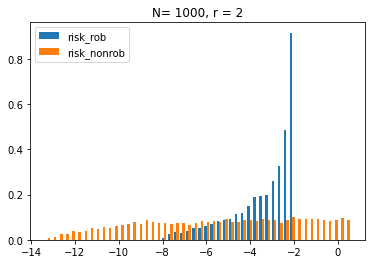

In [108]:
data1 = {'risk_rob':risk_rob, 'risk_nonrob': risk_nonrob}
dt1 = pd.DataFrame(data = data1)
plt.hist(dt1,density = True, bins = 50)
plt.legend(dt1.columns)
plt.title('N= 1000, r = 2')
plt.savefig('robustriskN1000_singpow2')

In [ ]:
prob = []            #alternative normal sampling
m = 3
for i in range(2000):
    q_real = np.zeros(m)
    for j in range(m-1):
        var = 1/2 * np.sqrt(r/3*p[j])
        continu = True
        while continu == True:
            q = np.random.normal(p[j],var)
            if q>= 0:
                continu = False
                q_real[j] = q
    last = 1-np.sum(q_real[0:m-1])
    if last >= 0:
        q_real[m-1] = last
        prob.append(q_real)

In [21]:
dt1

,risk_rob,risk_nonrob
0,-2.156183,-7.354122
1,-4.454042,-9.453175
2,-2.000000,-5.783862
3,-2.508950,-5.861010
4,-3.217887,-4.356681
...,...,...
1786,-3.181998,-4.910618
1787,-2.777919,-7.256492
1788,-2.752624,-8.524443
1789,-2.000000,-7.635048


In [374]:
def exp_news(p,d,par_news):
    N = len(p)
    [v_news, l_news, s_news, c_news] = par_news
    y = cp.Variable(1)
    l1 = (v_news+l_news-c_news)*y*(np.zeros(N)+1) - l_news*d
    l2 = (s_news-c_news)*y*(np.zeros(N)+1) + (v_news-s_news)*d
    z = cp.Variable(N)
    constraints = [y<= np.max(d), z <= l1, z <= l2]
    f_obj = 0
    for i in range(N):
        f_obj = f_obj + p[i]*z[i]
    obj = cp.Maximize(f_obj)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(y.value, prob.value)

In [40]:
r

0.6790336158551338

In [20]:
means_rob, means_nonrob = [np.zeros(3), np.zeros(3)]
max_rob, max_nonrob = [np.zeros(3), np.zeros(3)]
min_rob, min_nonrob = [np.zeros(3), np.zeros(3)]
worst_risk_rob, worst_risk_nonrob = [np.zeros(3), np.zeros(3)]

In [27]:
means_rob[2] = np.mean(risk_rob)
means_nonrob[2] = np.mean(risk_nonrob)
max_rob[2] = np.max(risk_rob)
max_nonrob[2] = np.max(risk_nonrob)
min_rob[2] = np.min(risk_rob)
min_nonrob[2] = np.min(risk_nonrob)
worst_risk_rob[2] = news_result[1]
worst_risk_nonrob[2] = news_nom_result[1]

In [28]:
print(np.round(means_rob,decimals = 3))
print(np.round(means_nonrob,decimals = 3))
print(np.round(max_rob,decimals=3))
print(np.round(max_nonrob,decimals = 3))
print(np.round(min_rob,decimals = 3))
print(np.round(min_nonrob,decimals=3))

[ 0.     0.    -3.366]
[ 0.     0.    -6.536]
[ 0.  0. -2.]
[0. 0. 2.]
[ 0.     0.    -9.838]
[  0.   0. -14.]
